In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

In [3]:
df = pd.read_csv("solution.csv")

x_cpp = df["x"]
y_cpp = df["y"]

In [4]:
def dSdt(x,y):
	return np.sin(x+y) - np.cos(x-y)

x_psol = np.arange(0.0,25.025,0.025)
sol = solve_ivp(fun=dSdt, t_span=[0.0,25.0],y0=[0.0], method="RK45", t_eval=x_psol)
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  2.500e-02 ...  2.498e+01  2.500e+01]
        y: [[ 0.000e+00 -2.499e-02 ...  1.805e-01  1.574e-01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 266
     njev: 0
      nlu: 0

In [5]:
y_psol = sol.y[0]
y_psol[0]

0.0

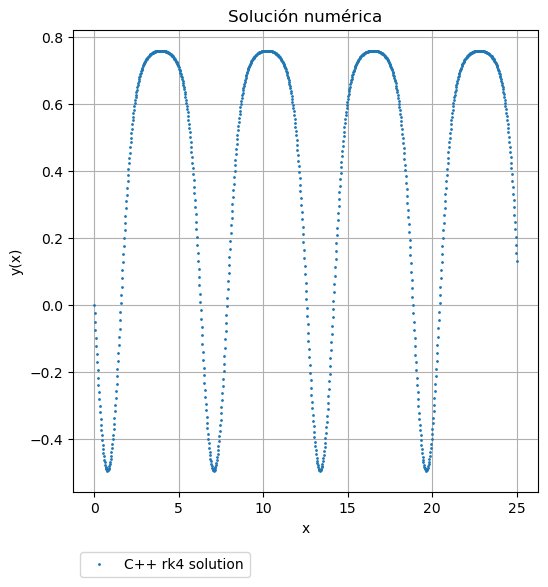

In [6]:
fig, ax = plt.subplots(1,1, figsize = (6,6))

#ax.plot(x_psol,y_psol, "o", ms = 1, label = "Scipy RK45")
ax.plot(x_cpp,y_cpp,"o",ms = 1, label = "C++ rk4 solution")


ax.set_title("Solución numérica")
ax.grid()
ax.legend(loc = "lower left",ncols = 2,  bbox_to_anchor=(0, -0.2))
ax.set_xlabel("x")
ax.set_ylabel("y(x)")
#plt.tight_layout() 
plt.savefig("solución.png")